# Create Spatial Subset of WRF-BCC Data for Demo
## Purpose
This notebook creates a spatially subset version of WRF-BCC precipitation data for demonstration purposes. The subset includes:
- **Spatial extent**: 50×50 grid cells from native 1399×899 domain
- **Region**: Meteorologically interesting area (e.g., Central Plains)
- **Temporal coverage**: 1-2 water years (e.g., 1990-1992)
- **Files created**:
  - Daily precipitation files with `_demo.nc` suffix
  - Geography (geom) file with `_demo.nc` suffix
  - Pre-calculated percentiles with `_demo.nc` suffix (if available)

## Output
Creates a laptop-friendly demo dataset (~few GB total vs. hundreds of GB for full domain)




In [1]:
# Import Libraries
from __future__ import annotations

import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
from tqdm import tqdm

%matplotlib inline



In [2]:
# Configuration

# Full WRF-BCC data paths
FULL_DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/historical"
FULL_GEOM_PATH = "/home/scratch/WRF_BCC/geography/geo_em.d01.nc"
FULL_PERCENTILE_PATH = "/home/scratch/sleake/AFWA_TOTPRECIP_15min_precip_periods/wet_period_percentiles_base0p254"

# Demo output paths
DEMO_OUTPUT_BASE = "./data/demo"
DEMO_PRECIP_PATH = os.path.join(DEMO_OUTPUT_BASE, "precipitation")
DEMO_GEOM_PATH = os.path.join(DEMO_OUTPUT_BASE, "geo_em_d01_demo.nc")
DEMO_PERCENTILE_PATH = os.path.join(DEMO_OUTPUT_BASE, "percentiles")

# Create output directories
os.makedirs(DEMO_PRECIP_PATH, exist_ok=True)
os.makedirs(DEMO_PERCENTILE_PATH, exist_ok=True)

print("Output directories created:")
print(f"  Precipitation: {DEMO_PRECIP_PATH}")
print(f"  Geography: {os.path.dirname(DEMO_GEOM_PATH)}")
print(f"  Percentiles: {DEMO_PERCENTILE_PATH}")



Output directories created:
  Precipitation: ./data/demo/precipitation
  Geography: ./data/demo
  Percentiles: ./data/demo/percentiles


In [3]:
# Define Spatial Subset Region

# Subset size (grid cells)
SUBSET_SIZE = 50  # 50×50 grid cells

# Option 1: Define by grid indices (recommended for simplicity)
# Choose a meteorologically interesting region
# Domain: south_north (0-898), west_east (0-1398)

# Central Plains region (good for MCS activity, severe weather)
# This is roughly over Oklahoma/Kansas area
START_SOUTH_NORTH = 400  # Example: middle of domain
START_WEST_EAST = 650     # Example: middle-eastern part

# Calculate end indices
END_SOUTH_NORTH = START_SOUTH_NORTH + SUBSET_SIZE
END_WEST_EAST = START_WEST_EAST + SUBSET_SIZE

print(f"Subset Configuration:")
print(f"  Size: {SUBSET_SIZE}×{SUBSET_SIZE} grid cells")
print(f"  South-North indices: {START_SOUTH_NORTH} to {END_SOUTH_NORTH}")
print(f"  West-East indices: {START_WEST_EAST} to {END_WEST_EAST}")
print(f"  Grid spacing: 3.75 km")
print(f"  Spatial extent: ~{SUBSET_SIZE*3.75:.1f} km × {SUBSET_SIZE*3.75:.1f} km")






Subset Configuration:
  Size: 50×50 grid cells
  South-North indices: 400 to 450
  West-East indices: 650 to 700
  Grid spacing: 3.75 km
  Spatial extent: ~187.5 km × 187.5 km


In [4]:
# Load Full Geom File and Extract Lat/Lon

print("Loading full geography file...")
geom_full = xr.open_dataset(FULL_GEOM_PATH, engine="netcdf4")

# Extract lat/lon coordinates
# WRF files typically have XLAT_M and XLONG_M (or XLAT and XLONG)
if 'XLAT_M' in geom_full.variables:
    lat_full = geom_full.XLAT_M.isel(Time=0).values
    lon_full = geom_full.XLONG_M.isel(Time=0).values
elif 'XLAT' in geom_full.variables:
    lat_full = geom_full.XLAT.isel(Time=0).values
    lon_full = geom_full.XLONG.isel(Time=0).values
else:
    print("Warning: Could not find XLAT/XLONG variables")
    lat_full = None
    lon_full = None

print(f"Full domain shape: {lat_full.shape}")
print(f"Full domain lat range: {lat_full.min():.2f}° to {lat_full.max():.2f}°")
print(f"Full domain lon range: {lon_full.min():.2f}° to {lon_full.max():.2f}°")




Loading full geography file...


/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfradial1' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'furuno' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gamic' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWa

Full domain shape: (899, 1399)
Full domain lat range: 20.51° to 53.46°
Full domain lon range: -133.66° to -61.34°


/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'iris' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'odim' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/anaconda3/envs/pyMET/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'rainbow' loading failed:
/anaconda3/envs/pyMET/lib/python3.10/site-packages/h5py/defs.cpython-310-x86_64-linux-gnu.so: undefined symbol: H5Pget_fapl_direct
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning

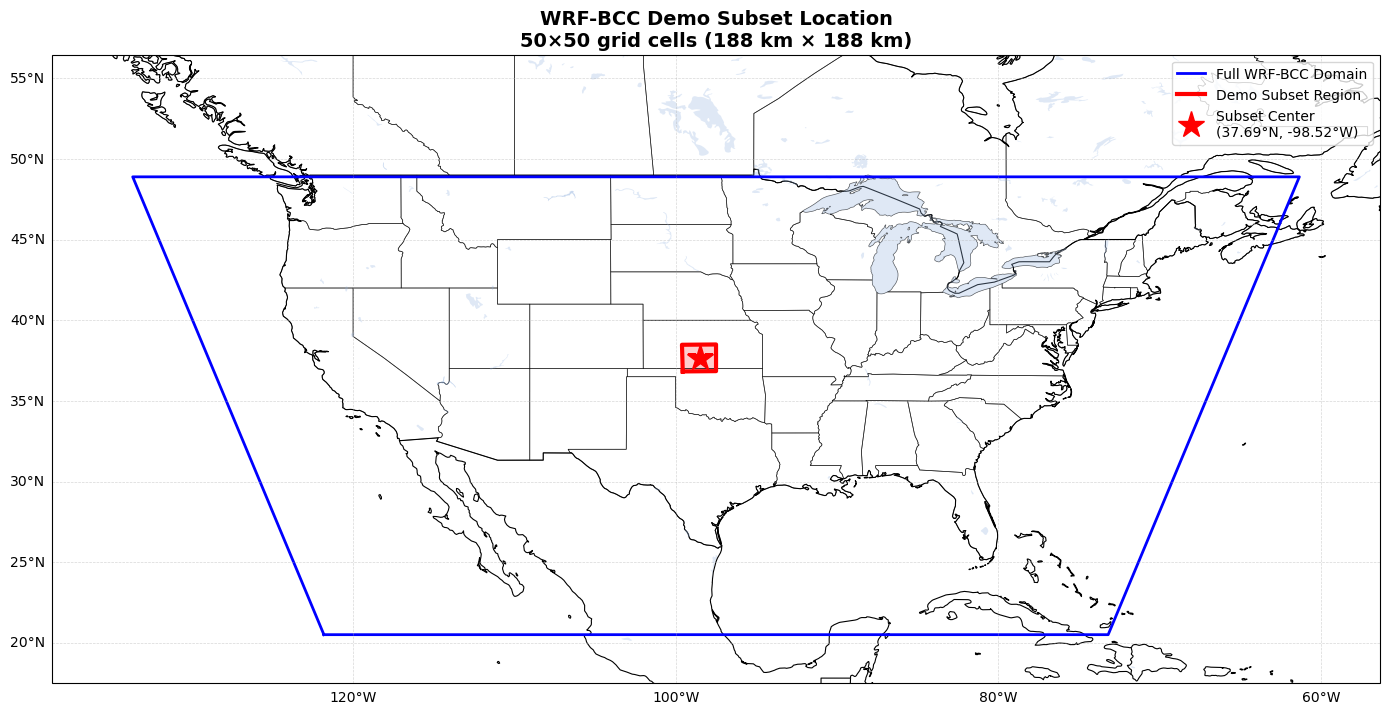


Subset Region Details:
  Center: 37.69°N, -98.52°W
  Lat range: 36.83° to 38.50°
  Lon range: -99.61° to -97.50°


In [5]:
# Visualize Subset Location on Full Domain

if lat_full is not None and lon_full is not None:
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.7)
    ax.add_feature(cfeature.LAKES, alpha=0.3)
    
    # Plot full domain boundary
    full_lons = [lon_full[0, 0], lon_full[0, -1], lon_full[-1, -1], lon_full[-1, 0], lon_full[0, 0]]
    full_lats = [lat_full[0, 0], lat_full[0, -1], lat_full[-1, -1], lat_full[-1, 0], lat_full[0, 0]]
    ax.plot(full_lons, full_lats, 'b-', linewidth=2, label='Full WRF-BCC Domain', 
            transform=ccrs.PlateCarree())
    
    # Plot subset boundary
    subset_lat = lat_full[START_SOUTH_NORTH:END_SOUTH_NORTH, START_WEST_EAST:END_WEST_EAST]
    subset_lon = lon_full[START_SOUTH_NORTH:END_SOUTH_NORTH, START_WEST_EAST:END_WEST_EAST]
    
    subset_lons = [subset_lon[0, 0], subset_lon[0, -1], subset_lon[-1, -1], 
                   subset_lon[-1, 0], subset_lon[0, 0]]
    subset_lats = [subset_lat[0, 0], subset_lat[0, -1], subset_lat[-1, -1], 
                   subset_lat[-1, 0], subset_lat[0, 0]]
    ax.plot(subset_lons, subset_lats, 'r-', linewidth=3, label='Demo Subset Region', 
            transform=ccrs.PlateCarree())
    ax.fill(subset_lons, subset_lats, color='red', alpha=0.2, transform=ccrs.PlateCarree())
    
    # Add center point
    center_lat = subset_lat[SUBSET_SIZE//2, SUBSET_SIZE//2]
    center_lon = subset_lon[SUBSET_SIZE//2, SUBSET_SIZE//2]
    ax.plot(center_lon, center_lat, 'r*', markersize=20, label=f'Subset Center\n({center_lat:.2f}°N, {center_lon:.2f}°W)',
            transform=ccrs.PlateCarree())
    
    # Set extent to show full domain with some padding
    lon_padding = 5
    lat_padding = 3
    ax.set_extent([lon_full.min() - lon_padding, lon_full.max() + lon_padding,
                   lat_full.min() - lat_padding, lat_full.max() + lat_padding],
                  crs=ccrs.PlateCarree())
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.legend(loc='upper right', fontsize=10)
    plt.title(f'WRF-BCC Demo Subset Location\n{SUBSET_SIZE}×{SUBSET_SIZE} grid cells ({SUBSET_SIZE*3.75:.0f} km × {SUBSET_SIZE*3.75:.0f} km)', 
              fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print subset info
    print(f"\nSubset Region Details:")
    print(f"  Center: {center_lat:.2f}°N, {center_lon:.2f}°W")
    print(f"  Lat range: {subset_lat.min():.2f}° to {subset_lat.max():.2f}°")
    print(f"  Lon range: {subset_lon.min():.2f}° to {subset_lon.max():.2f}°")
else:
    print("Skipping visualization - could not extract lat/lon coordinates")




In [6]:
# Create Subset Geom File

print("\n" + "="*60)
print("Creating subset geography file...")
print("="*60)

# Subset the geom file
geom_subset = geom_full.isel(
    south_north=slice(START_SOUTH_NORTH, END_SOUTH_NORTH),
    west_east=slice(START_WEST_EAST, END_WEST_EAST)
)

# Also subset staggered dimensions if they exist
if 'south_north_stag' in geom_full.dims:
    geom_subset = geom_subset.isel(
        south_north_stag=slice(START_SOUTH_NORTH, END_SOUTH_NORTH + 1)
    )
if 'west_east_stag' in geom_full.dims:
    geom_subset = geom_subset.isel(
        west_east_stag=slice(START_WEST_EAST, END_WEST_EAST + 1)
    )

# Update metadata to reflect subset
geom_subset.attrs['WEST-EAST_GRID_DIMENSION'] = SUBSET_SIZE + 1
geom_subset.attrs['SOUTH-NORTH_GRID_DIMENSION'] = SUBSET_SIZE + 1
geom_subset.attrs['WEST-EAST_PATCH_END_UNSTAG'] = SUBSET_SIZE
geom_subset.attrs['SOUTH-NORTH_PATCH_END_UNSTAG'] = SUBSET_SIZE
geom_subset.attrs['WEST-EAST_PATCH_END_STAG'] = SUBSET_SIZE + 1
geom_subset.attrs['SOUTH-NORTH_PATCH_END_STAG'] = SUBSET_SIZE + 1

# Add demo-specific metadata
geom_subset.attrs['DEMO_SUBSET'] = 'True'
geom_subset.attrs['DEMO_SUBSET_SIZE'] = SUBSET_SIZE
geom_subset.attrs['DEMO_START_SOUTH_NORTH'] = START_SOUTH_NORTH
geom_subset.attrs['DEMO_START_WEST_EAST'] = START_WEST_EAST
geom_subset.attrs['DEMO_END_SOUTH_NORTH'] = END_SOUTH_NORTH
geom_subset.attrs['DEMO_END_WEST_EAST'] = END_WEST_EAST
geom_subset.attrs['DEMO_CREATION_DATE'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
geom_subset.attrs['DEMO_NOTE'] = f'Spatial subset of WRF-BCC for demonstration purposes'

# Save subset geom file
print(f"Saving to: {DEMO_GEOM_PATH}")
geom_subset.to_netcdf(DEMO_GEOM_PATH, mode='w')

print(f"  Subset geom file created")
print(f"  Original shape: {geom_full.dims['south_north']}×{geom_full.dims['west_east']}")
print(f"  Subset shape: {geom_subset.dims['south_north']}×{geom_subset.dims['west_east']}")

# Calculate size reduction
original_size_mb = 500  # Approximate original file size
subset_ratio = (SUBSET_SIZE**2) / (geom_full.dims['south_north'] * geom_full.dims['west_east'])
estimated_size_mb = original_size_mb * subset_ratio
print(f"  Estimated size reduction: ~{subset_ratio*100:.2f}% of original")

# Clean up
geom_full.close()
geom_subset.close()


Creating subset geography file...
Saving to: ./data/demo/geo_em_d01_demo.nc
✓ Subset geom file created
  Original shape: 899×1399
  Subset shape: 50×50
  Estimated size reduction: ~0.20% of original


In [7]:
# Define Date Range for Demo Data

# Demo temporal coverage (1-2 water years)
DEMO_START_YEAR = 1990
DEMO_END_YEAR = 1992  # Will process 1990-1991 and 1991-1992 water years

print(f"\nDemo temporal coverage:")
print(f"  Water years: {DEMO_START_YEAR}-{DEMO_START_YEAR+1} and {DEMO_END_YEAR-1}-{DEMO_END_YEAR}")
print(f"  Date range: {DEMO_START_YEAR}-10-01 to {DEMO_END_YEAR}-09-30")

# Generate list of dates to process
start_date = datetime(DEMO_START_YEAR, 10, 1)
end_date = datetime(DEMO_END_YEAR, 9, 30)

dates_to_process = []
current_date = start_date
while current_date <= end_date:
    dates_to_process.append(current_date)
    current_date += timedelta(days=1)

print(f"  Total days to process: {len(dates_to_process)}")
print(f"  Expected total size: ~{len(dates_to_process) * estimated_size_mb / 1024:.1f} GB")



Demo temporal coverage:
  Water years: 1990-1991 and 1991-1992
  Date range: 1990-10-01 to 1992-09-30
  Total days to process: 731
  Expected total size: ~0.7 GB


In [8]:
# Process Daily Precipitation Files

print("\n" + "="*40)
print("Creating subset precipitation files...")
print("="*40)

processed_count = 0
error_count = 0
skipped_count = 0

for date in tqdm(dates_to_process, desc="Processing daily files"):
    year = date.year
    month = date.month
    day = date.day
    
    # Determine folder year (water year starts Oct 1)
    if month >= 10:
        folder_year = year
    else:
        folder_year = year - 1
    
    # Construct input file path
    input_file = os.path.join(
        FULL_DATA_PATH,
        f"{folder_year}-{folder_year+1}",
        f"AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
    )
    
    # Construct output file path (simplified structure, no subdirectories)
    output_file = os.path.join(
        DEMO_PRECIP_PATH,
        f"AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}_demo.nc"
    )
    
    # Skip if output already exists
    if os.path.exists(output_file):
        skipped_count += 1
        continue
    
    # Check if input file exists
    if not os.path.exists(input_file):
        error_count += 1
        print(f"\nWarning: Input file not found: {input_file}")
        continue
    
    try:
        # Load the full daily file
        ds_full = xr.open_dataset(input_file, engine="netcdf4")
        
        # Subset spatially
        ds_subset = ds_full.isel(
            south_north=slice(START_SOUTH_NORTH, END_SOUTH_NORTH),
            west_east=slice(START_WEST_EAST, END_WEST_EAST)
        )
        
        # Update metadata
        ds_subset.attrs['WEST-EAST_PATCH_END_UNSTAG'] = SUBSET_SIZE
        ds_subset.attrs['SOUTH-NORTH_PATCH_END_UNSTAG'] = SUBSET_SIZE
        
        # Add demo-specific metadata
        ds_subset.attrs['DEMO_SUBSET'] = 'True'
        ds_subset.attrs['DEMO_SUBSET_SIZE'] = SUBSET_SIZE
        ds_subset.attrs['DEMO_START_SOUTH_NORTH'] = START_SOUTH_NORTH
        ds_subset.attrs['DEMO_START_WEST_EAST'] = START_WEST_EAST
        ds_subset.attrs['DEMO_NOTE'] = f'Spatial subset of WRF-BCC for demonstration'
        
        # Save subset file
        ds_subset.to_netcdf(output_file, mode='w')
        
        # Clean up
        ds_full.close()
        ds_subset.close()
        
        processed_count += 1
        
    except Exception as e:
        error_count += 1
        print(f"\nError processing {input_file}: {str(e)}")

print(f"\n" + "="*40)
print("Processing Summary:")
print(f"  Files processed: {processed_count}")
print(f"  Files skipped (already exist): {skipped_count}")
print(f"  Errors: {error_count}")
print(f"  Total files: {len(dates_to_process)}")
print("="*40)




Creating subset precipitation files...


Processing daily files:  71%|███████   | 516/731 [38:03<15:51,  4.43s/it]

Processing daily files: 100%|██████████| 731/731 [53:48<00:00,  4.42s/it]


Processing Summary:
  Files processed: 730
  Files skipped (already exist): 0
  Errors: 1
  Total files: 731


In [15]:
# Create Subset Percentile Files

print("\n" + "="*40)
print("Creating subset percentile files...")
print("="*40)

# Correct path to percentile files
FULL_PERCENTILE_PATH = "/home/scratch/sleake/AFWA_TOTPRECIP_15min_precip_periods/wet_period_percentiles_base0p254"

# List of season identifiers to process
seasons = ['MAM', 'JJA', 'SON', 'DJF', 'ALL']

percentile_processed = 0
percentile_errors = 0
percentile_skipped = 0

for season in seasons:
    # Construct input percentile file path
    input_percentile = os.path.join(
        FULL_PERCENTILE_PATH,
        f"historical_{season}_quantiles_gt0p254.nc"
    )
    
    # Construct output percentile file path
    output_percentile = os.path.join(
        DEMO_PERCENTILE_PATH,
        f"historical_{season}_quantiles_gt0p254_demo.nc"
    )
    
    # Skip if output already exists
    if os.path.exists(output_percentile):
        print(f"  {season}: Already exists, skipping")
        percentile_skipped += 1
        continue
    
    # Check if input exists
    if not os.path.exists(input_percentile):
        print(f"  {season}: Input file not found at {input_percentile}")
        percentile_errors += 1
        continue
    
    try:
        print(f"  Processing {season}...")
        
        # Load full percentile file
        perc_full = xr.open_dataset(input_percentile, engine="netcdf4")
        
        print(f"    Original shape: {perc_full.AFWA_TOTPRECIP.shape}")
        print(f"    Quantiles: {perc_full.dims['quantile']} values")
        
        # Subset spatially (keep all quantile values)
        perc_subset = perc_full.isel(
            south_north=slice(START_SOUTH_NORTH, END_SOUTH_NORTH),
            west_east=slice(START_WEST_EAST, END_WEST_EAST)
        )
        
        print(f"    Subset shape: {perc_subset.AFWA_TOTPRECIP.shape}")
        
        # Verify quantile dimension is preserved (use dims, not len())
        if perc_subset.dims['quantile'] != perc_full.dims['quantile']:
            raise ValueError(f"Quantile dimension was not preserved! "
                           f"Original: {perc_full.dims['quantile']}, "
                           f"Subset: {perc_subset.dims['quantile']}")
        
        # Add demo metadata
        perc_subset.attrs['DEMO_SUBSET'] = 'True'
        perc_subset.attrs['DEMO_SUBSET_SIZE'] = SUBSET_SIZE
        perc_subset.attrs['DEMO_START_SOUTH_NORTH'] = START_SOUTH_NORTH
        perc_subset.attrs['DEMO_START_WEST_EAST'] = START_WEST_EAST
        perc_subset.attrs['DEMO_NOTE'] = 'Spatial subset of percentiles for demonstration'
        perc_subset.attrs['DEMO_CREATION_DATE'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        
        # Save subset percentile file
        print(f"    Saving to: {output_percentile}")
        perc_subset.to_netcdf(output_percentile, mode='w')
        
        # Calculate file sizes
        input_size_mb = os.path.getsize(input_percentile) / (1024**2)
        output_size_mb = os.path.getsize(output_percentile) / (1024**2)
        reduction = (1 - output_size_mb/input_size_mb) * 100
        
        print(f"    Created: {output_size_mb:.1f} MB (original: {input_size_mb:.1f} MB, {reduction:.1f}% reduction)")
        
        # Clean up
        perc_full.close()
        perc_subset.close()
        
        percentile_processed += 1
        
    except Exception as e:
        percentile_errors += 1
        print(f"  Error processing {season}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*40}")
print(f"Percentile Processing Summary:")
print(f"  Files processed: {percentile_processed}")
print(f"  Files skipped (already exist): {percentile_skipped}")
print(f"  Errors: {percentile_errors}")
print(f"  Total expected: {len(seasons)}")
print(f"{'='*40}")

# List output files
if percentile_processed > 0 or percentile_skipped > 0:
    print(f"\nOutput percentile files:")
    for season in seasons:
        output_file = os.path.join(DEMO_PERCENTILE_PATH, f"historical_{season}_quantiles_gt0p254_demo.nc")
        if os.path.exists(output_file):
            size_mb = os.path.getsize(output_file) / (1024**2)
            print(f"  {season}: {size_mb:.1f} MB")


Creating subset percentile files...
  Processing MAM...
    Original shape: (27, 899, 1399)
    Quantiles: 27 values
    Subset shape: (27, 50, 50)
    Saving to: ./data/demo/percentiles/historical_MAM_quantiles_gt0p254_demo.nc
    Created: 0.3 MB (original: 129.5 MB, 99.8% reduction)
  Processing JJA...
    Original shape: (27, 899, 1399)
    Quantiles: 27 values
    Subset shape: (27, 50, 50)
    Saving to: ./data/demo/percentiles/historical_JJA_quantiles_gt0p254_demo.nc
    Created: 0.3 MB (original: 129.5 MB, 99.8% reduction)
  Processing SON...
    Original shape: (27, 899, 1399)
    Quantiles: 27 values
    Subset shape: (27, 50, 50)
    Saving to: ./data/demo/percentiles/historical_SON_quantiles_gt0p254_demo.nc
    Created: 0.3 MB (original: 129.5 MB, 99.8% reduction)
  Processing DJF...
    Original shape: (27, 899, 1399)
    Quantiles: 27 values
    Subset shape: (27, 50, 50)
    Saving to: ./data/demo/percentiles/historical_DJF_quantiles_gt0p254_demo.nc
    Created: 0.3 MB (